<a href="https://colab.research.google.com/github/Hkd225/yolov8-smoke-fire-detection/blob/main/yolo_api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import kagglehub
path = kagglehub.dataset_download("sayedgamal99/smoke-fire-detection-yolo")


Using Colab cache for faster access to the 'smoke-fire-detection-yolo' dataset.


In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.8 MB/s eta 0:00:00


In [3]:
# ==========================================
# 1. SETUP & DOWNLOAD DATASET D-FIRE
# ==========================================
import os
import yaml
import kagglehub
from ultralytics import YOLO

print("Mendownload dataset D-Fire dari Kaggle...")
# Download dataset menggunakan kagglehub
base_path = kagglehub.dataset_download("sayedgamal99/smoke-fire-detection-yolo")
print(f"Dataset berhasil didownload dan tersimpan di:\n👉 {base_path}\n")

# Path yaml bawaan dataset yang memiliki path salah
original_yaml_path = os.path.join(base_path, "data.yaml")

# --- MULAI PERBAIKAN DATA.YAML ---
print("Memperbaiki path di dalam data.yaml...")
with open(original_yaml_path, 'r') as file:
    data_yaml = yaml.safe_load(file)

# Set path utama ke lokasi dataset yang sebenarnya (di dalam sub-folder 'data')
data_yaml['path'] = os.path.join(base_path, "data")

# Sesuaikan lokasi train, val, dan test
data_yaml['train'] = "train/images"
data_yaml['val'] = "val/images"
data_yaml['test'] = "test/images"

# Simpan sebagai yaml baru di /content/ agar Colab & YOLO memiliki akses penuh
new_yaml_path = "/content/data_fixed.yaml"
with open(new_yaml_path, 'w') as file:
    yaml.dump(data_yaml, file)

print(f"File konfigurasi baru berhasil dibuat di:\n👉 {new_yaml_path}\n")
# --- SELESAI PERBAIKAN ---


# ==========================================
# 2. LOAD MODEL & TRAINING OBJECT DETECTION
# ==========================================
print("Memuat pre-trained model YOLO Object Detection (yolov8n.pt)...")
# Menggunakan yolov8n.pt (TANPA -cls) agar memunculkan bounding box
model = YOLO('yolov8n.pt')

print("\nMemulai proses training...")
results = model.train(
    data=new_yaml_path,      # PERHATIKAN: Kita gunakan yaml baru yang sudah diperbaiki
    epochs=15,               # Jumlah iterasi belajar
    imgsz=640,               # Resolusi standar untuk object detection
    batch=16,                # Ukuran batch
    project='fire_detect_project', # Nama folder utama proyek
    name='run_1'             # Nama folder percobaan ini
)

print("\nProses training selesai!")
print("Model terbaik Anda otomatis disimpan oleh YOLO di:")
print("👉 /content/fire_detect_project/run_1/weights/best.pt 👈")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mendownload dataset D-Fire dari Kaggle...
Using Colab cache for faster access to the 'smoke-fire-detection-yolo' dataset.
Dataset berhasil didownload dan tersimpan di:
👉 /kaggle/input/smoke-fire-detection-yolo

Memperbaiki path di dalam data.yaml...
File konfigurasi baru berhasil dibuat di:
👉 /content/data_fixed.yaml

Memuat pre-trained model YOLO Object Detection (yolov8n.pt)...

Memulai proses training...
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw

Silakan upload gambar untuk mendeteksi Api dan Asap:


Saving images (5).jpg to images (5).jpg

Menganalisis gambar: images (5).jpg...

image 1/1 /content/images (5).jpg: 640x480 1 smoke, 3 fires, 181.5ms
Speed: 3.6ms preprocess, 181.5ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)


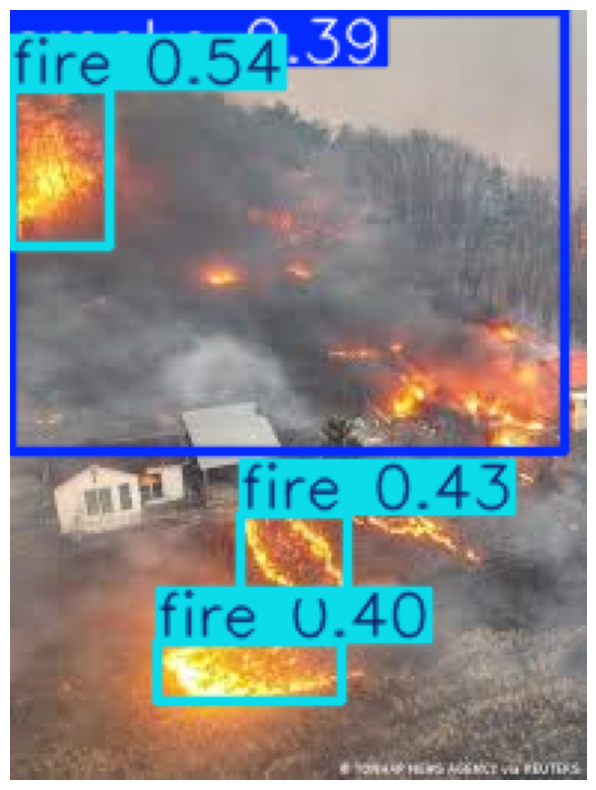

In [4]:
# ==========================================
# TESTING MODEL OBJECT DETECTION
# ==========================================
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from ultralytics import YOLO

# Sesuaikan dengan lokasi penyimpanan best.pt yang baru
model_path = 'best.pt'
model_best = YOLO(model_path)

print("Silakan upload gambar untuk mendeteksi Api dan Asap:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'\nMenganalisis gambar: {filename}...')

    # 1. Jalankan prediksi (conf=0.25 artinya abaikan deteksi yang keyakinannya di bawah 25%)
    results = model_best(filename, conf=0.25)

    # 2. Plotting Otomatis! (YOLO yang akan menggambar kotaknya)
    res_plotted = results[0].plot()

    # 3. Konversi warna untuk ditampilkan di Matplotlib
    res_plotted = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    # 4. Tampilkan gambar
    plt.figure(figsize=(10, 10))
    plt.imshow(res_plotted)
    plt.axis('off')
    plt.show()